<center>
<font size=+4>Python Personal Project</font><br/>
<font size=+2> Data Analysis for Heart Disease Prediction</font>
</center>



## 1) **General Description of the Dataset**


- **Context:** Heart disease is the leading cause of death in developed countries, emphasizing the need for taking effective steps towards reducing the risk of heart attacks and strokes.


- **Content:** The dataset of interest, downloaded from Kaggle webstie, is a modified version of the 'Cleveland Dataset' which a well-known clinical dataset widely used for Machine Learning purposes. It contains patient statistics along with key clinical parameters recorded during hospital visits. The link to access the dataset on Kaggle is provided below: https://www.kaggle.com/datasets/rishidamarla/heart-disease-prediction/code


- **Aim:** The present project aims to perform exploratory data analysis on the dataset in order to gain insights for formulating questions that can that can guide strategies for reducing heart disease risk. Ultimately, a machine learning classification algorithm will be employed to predict the likelihood of patients developing heart disease in the near future based on the provided features.


## 2) **Data Import, Cleaning, and Verification (*Data Pre-processing*)** ##


In [1]:
#Importing necessary libraries 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import HTML # For styling the descriptive textx


In [2]:
# Importing Dataset

heart = pd.read_csv("Heart_Disease_Prediction.csv")
heart


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [3]:
# Getting an overview of the original raw dataset

heart.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 


According to the information from the **"info()"** output, there are no missing values in the dataset. However, there are still several pre-processing steps required for the raw dataset, which will be preformed in 3 main subsections.












 
### 2-1) Deleting Columns With Unclear Description: ###

Since the definitions for two parameters ("Number of vessels fluro" and "Thallium") were unclear,these two columns need to be removed from the dataset to simplify the analysis.

In [4]:
heart_modified = heart.drop(["Number of vessels fluro", "Thallium"], axis=1)
heart_modified


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,Absence



This modified dataset includes 12 features, each described below:

1. **Age**: Age of the patient in years.

2. **Sex**: Gender of the patient.  ( 1 = *Male* ;  0 = *Female* )
 
3. **Chest Pain Type**: Type of chest pain experienced by the patient.  (1 = *Typical angina* , 2 = *Atypical angina* , 3 = *Non-anginal pain* , 4 = *Asymptomatic*
       
4. **BP**: Resting blood pressure measured in mm Hg upon admission to the hospital.

5. **Cholesterol**: Serum cholesterol level in mg/dl.

6. **FBS over 120**: Whether the patient's fasting blood sugar is greater than 120 mg/dl (1 = True, 0 = False)

7. **EKG Results**: Results of the resting electrocardiogram. (0 = *Normal* , 1 = *ST-T wave abnormality* , 2 = *Probable or definite left ventricular hypertrophy by Estes' criteria*

8. **Max HR**: Maximum heart rate achieved during exercise.

9. **Exercise Angina**: Whether angina was induced by exercise.  (1 = *Yes* ; 0 = *No*)

10. **ST Depression**: ST depression induced by exercise, measured relative to rest.

11. **Slope of ST**: Slope of the peak exercise ST segment (1 = *Upsloping*  ; 2 = *Flat*  ; 3 = *Downsloping*)

12. **Heart Disease**: Presence of heart disease (1 = *Presence* ;  0 = *Absence*)


### 2-2) Renaming Columns: ###

According to the descriptions, some column names can be renamed to be more expressive so that any misinterpretations in future. Therefore, the columns were renamed properly.


In [5]:
# Renaming columns in format of a dictionary

heart_modified = heart_modified.rename(columns=
                                       {
                                        "BP": "Resting Blood Pressure",
                                        "Chest pain type": "Chest Pain Type",
                                        "Cholesterol": "Serum Cholestrol ",
                                        "FBS over 120": "Fasting Blood Sugar over 120",
                                        "Max HR": "Maximum Heart Rate",
                                        "Exercise angina": "Exercise-Induced Angina",
                                        "ST depression": "S_T Depression Relative to Rest",
                                        "Slope of ST": "S_T Slope Relative to Rest"
                                       })

heart_modified

,Age,Sex,Chest Pain Type,Resting Blood Pressure,Serum Cholestrol,Fasting Blood Sugar over 120,EKG results,Maximum Heart Rate,Exercise-Induced Angina,S_T Depression Relative to Rest,S_T Slope Relative to Rest,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,Absence


### 2-3) Adjusting Data Types ###

Several columns have incorrect data types, which can potentially cause issues during the Machine Learning (ML) process in subsequent sections. In particular, there are categorical features which are originally represented as floats or integers because they have been assigned numerical values. Therefore, the data types need to be adjusted accordingly.


In [6]:
# Adjusting data types

heart_modified = heart_modified.astype(
                                      {   
                                      "Sex":"category",
                                      "Chest Pain Type" : "category",
                                      "Fasting Blood Sugar over 120" : "category",
                                      "EKG results" : "category",
                                      "Exercise-Induced Angina":"category",
                                      "S_T Slope Relative to Rest":"category",
                                      "Heart Disease" : "category"
                                      })

heart_modified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Age                              270 non-null    int64   
 1   Sex                              270 non-null    category
 2   Chest Pain Type                  270 non-null    category
 3   Resting Blood Pressure           270 non-null    int64   
 4   Serum Cholestrol                 270 non-null    int64   
 5   Fasting Blood Sugar over 120     270 non-null    category
 6   EKG results                      270 non-null    category
 7   Maximum Heart Rate               270 non-null    int64   
 8   Exercise-Induced Angina          270 non-null    category
 9   S_T Depression Relative to Rest  270 non-null    float64 
 10  S_T Slope Relative to Rest       270 non-null    category
 11  Heart Disease                    270 non-null    category
dtypes: categ

As shown in the output, The feature names as weel as the data types have been corrected. The final step is to replace the misleading numerical values for all the categorical features.


### 2-4) Replacing Unnecessary Numerical Values with Categorical Strings ###

In [7]:
# Getting columns with categorical data types first:

heart_modified.select_dtypes('category')


,Sex,Chest Pain Type,Fasting Blood Sugar over 120,EKG results,Exercise-Induced Angina,S_T Slope Relative to Rest,Heart Disease
0,1,4,0,2,0,2,Presence
1,0,3,0,2,0,2,Absence
2,1,2,0,0,0,1,Presence
3,1,4,0,0,1,2,Absence
4,0,2,0,2,1,1,Absence
...,...,...,...,...,...,...,...
265,1,3,1,0,0,1,Absence
266,1,2,0,0,0,1,Absence
267,0,2,0,2,0,2,Absence
268,1,4,0,0,0,2,Absence


In [8]:
# "Sex" column

heart_modified['Sex'] = heart_modified['Sex'].replace({1: 'Male', 0: 'Female'})

# "Fasting Blood Sugar over 120" column

heart_modified['Fasting Blood Sugar over 120'] = heart_modified['Fasting Blood Sugar over 120'].replace({1: 'Yes', 0: 'No'})

# "EKG results" column

heart_modified['EKG results'] = heart_modified['EKG results'].replace({0: 'Normal', 1: 'ST-T Abnormality' , 2: 'Left Ventricular Hypertrophy'})

# "Exercise-Induced Angina" column

heart_modified['Exercise-Induced Angina'] = heart_modified['Exercise-Induced Angina'].replace({1: 'Yes', 0: 'No'})

# "S_T Slope Relative to Rest" column

heart_modified['S_T Slope Relative to Rest'] = heart_modified['S_T Slope Relative to Rest'].replace({1: 'Upsolopping', 2: 'Flat' , 3: 'Downslopping'})

# Using loc command for Chest pain type


heart_modified['Chest Pain Type'] = heart_modified['Chest Pain Type'].replace({1: 'Typical Angina', 2: 'Atypical Angina' , 3: 'Non-anginal pain' , 4: "Asymptomatic"})


heart_modified


,Age,Sex,Chest Pain Type,Resting Blood Pressure,Serum Cholestrol,Fasting Blood Sugar over 120,EKG results,Maximum Heart Rate,Exercise-Induced Angina,S_T Depression Relative to Rest,S_T Slope Relative to Rest,Heart Disease
0,70,Male,Asymptomatic,130,322,No,Left Ventricular Hypertrophy,109,No,2.4,Flat,Presence
1,67,Female,Non-anginal pain,115,564,No,Left Ventricular Hypertrophy,160,No,1.6,Flat,Absence
2,57,Male,Atypical Angina,124,261,No,Normal,141,No,0.3,Upsolopping,Presence
3,64,Male,Asymptomatic,128,263,No,Normal,105,Yes,0.2,Flat,Absence
4,74,Female,Atypical Angina,120,269,No,Left Ventricular Hypertrophy,121,Yes,0.2,Upsolopping,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,Male,Non-anginal pain,172,199,Yes,Normal,162,No,0.5,Upsolopping,Absence
266,44,Male,Atypical Angina,120,263,No,Normal,173,No,0.0,Upsolopping,Absence
267,56,Female,Atypical Angina,140,294,No,Left Ventricular Hypertrophy,153,No,1.3,Flat,Absence
268,57,Male,Asymptomatic,140,192,No,Normal,148,No,0.4,Flat,Absence


At this point, the data pre-processing steps are finished and we can furthur proceeed with Exploratory data analysis

## 3) **Initial Data Exploration** ## 


The initial step in understanding the heart disease dataset involved performing exploratory data analysis (EDA) to visualize and summarize both numerical and categorical variables. This process is essential for detecting patterns, spotting anomalies, and identifying relationships between variables, which are all crucial for developing predictive models.

### 3-1) Visualization of Numerical Variables

In [9]:
heart_modified.describe()

,Age,Resting Blood Pressure,Serum Cholestrol,Maximum Heart Rate,S_T Depression Relative to Rest
count,270.000000,270.000000,270.000000,270.000000,270.00000
mean,54.433333,131.344444,249.659259,149.677778,1.05000
std,9.109067,17.861608,51.686237,23.165717,1.14521
min,29.000000,94.000000,126.000000,71.000000,0.00000
25%,48.000000,120.000000,213.000000,133.000000,0.00000
50%,55.000000,130.000000,245.000000,153.500000,0.80000
75%,61.000000,140.000000,280.000000,166.000000,1.60000
max,77.000000,200.000000,564.000000,202.000000,6.20000


#### 3-1-1) Distribution of the Numerical variables ####

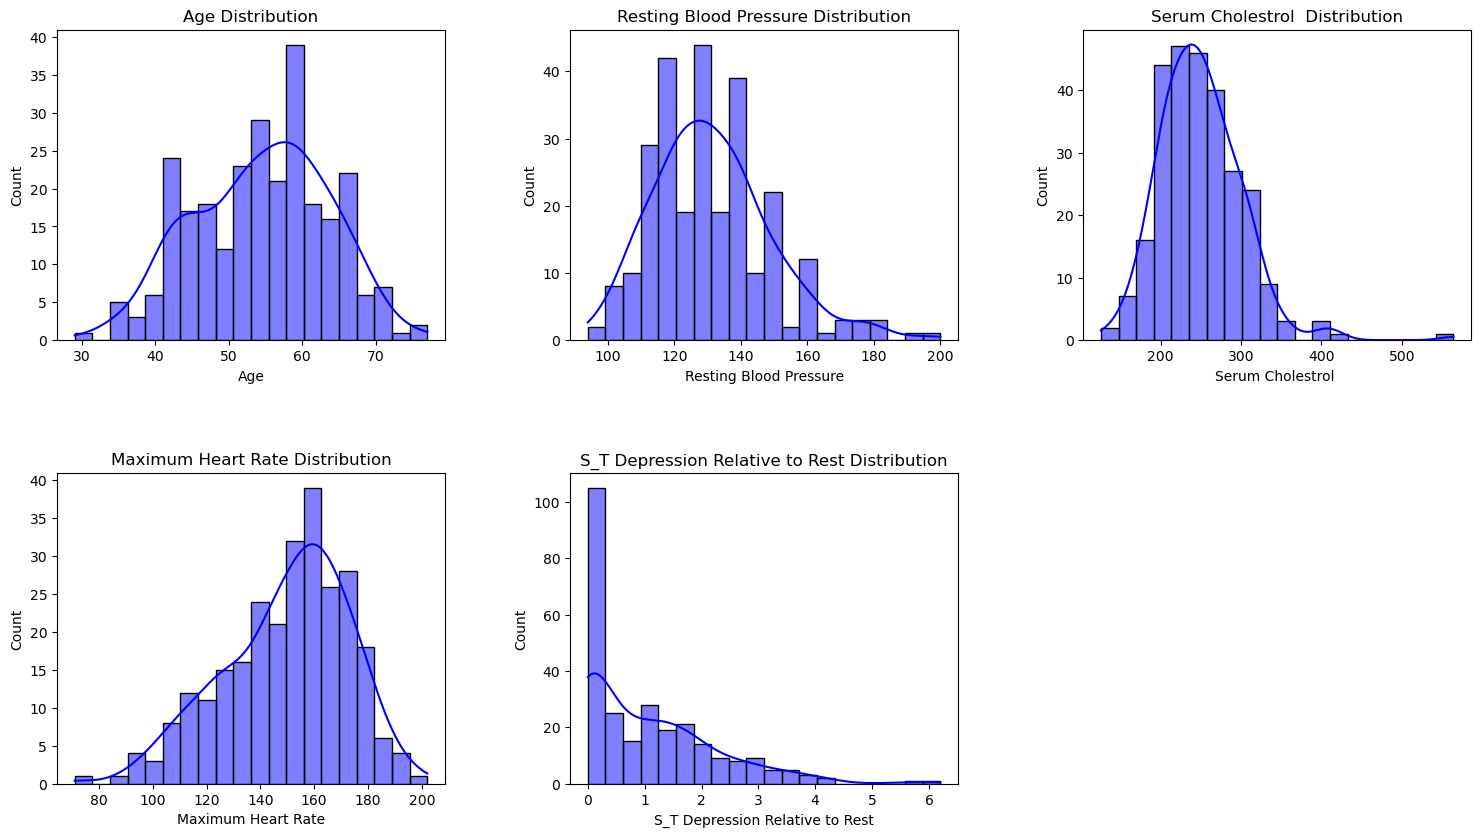

In [10]:
# Visualize distribution of numerical variables using histograms

# Iterating through numerical columns
numerical_cols = heart_modified.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(16, 18))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4,3 , i)  
    sns.histplot(heart_modified[col], bins=20, kde=True, color='blue')
    plt.title(f'{col} Distribution')
plt.tight_layout(pad=5)
plt.show()


We visualized the distribution of the numerical features using histograms. The numerical variables examined include Age, Resting Blood Pressure, Cholesterol, and Maximum Heart Rate. The above histograms provide insights into the central tendencies, spread, and outliers of the data.

***Age:*** The distribution of age shows that most patients are middle-aged or older. This is confirmed by the data from describe() function, which indicates that the youngest subject is 29 years old and the mean age of subjects is almost 55 years old. The smooth curve distributions show that the dataset appears to have a slightly skewed distribution toward older patients, with fewer patients in the younger age brackets.

***Resting Blood Pressure:*** The majority of subjects have blood pressure values ranging between 120 and 140 mmHg, but there are some extreme values that exceed 160 mmHg. This high blood pressure can possibly be considered as a risk factor for heart disease.

***Cholesterol:*** The cholesterol levels display a wide range, with a significant portion of the subjects having cholesterol levels above 200 mg/dl, indicating a potential risk for heart disease.

***Maximum Heart Rate:*** The distribution of maximum heart rates varies, with most patients achieving a rate between 140 and 180 beats per minute. Lower maximum heart rates could suggest heart conditions or limited physical fitness.

***Maximum Heart Rate:*** The distribution of maximum heart rates varies, with most patients achieving a rate between 140 and 180 beats per minute. Lower maximum heart rates could suggest heart conditions or limited physical fitness.



#### 3-1-2) Correlation Analysis ####

<Axes: >

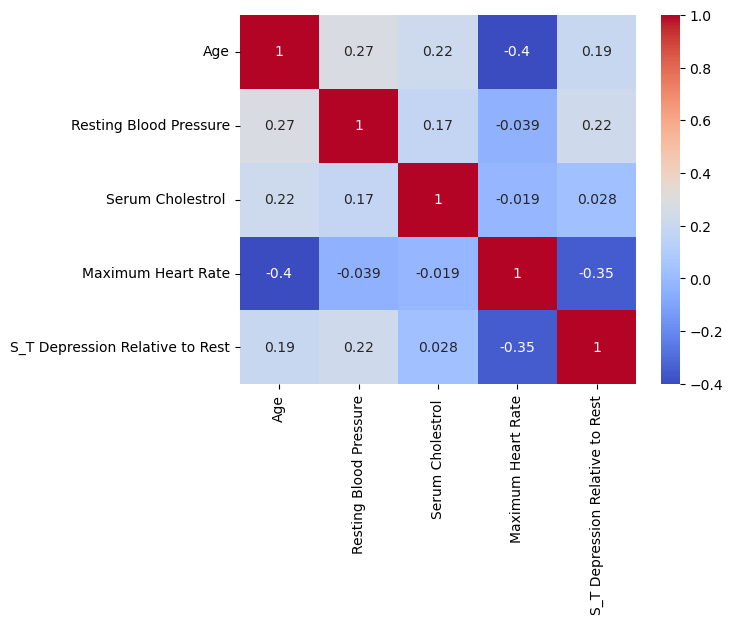

In [11]:
# Generating heatmap to gain insights into the relationships between continuous variables

correlation_matrix = heart_modified.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')


In the represented heatmap, 3 classes of correlation coefficients can be observed, which we can describe as follows:

**1) Positive values:** Positive correlation coefficient between two variables imply that as one of them tends to increase, the other one will also increase. In other words, they have coordinated trends.

**2) Negative values:** Negative correlation coefficient between varibales implies an antagonistic trend, meaning that one variable tends to decrease as the other increases.
  
**3) Close-to-zero values:** Such correlation coefficients indicate that there is almost no correlation or a very weak correlation between variables.

As we can observe, there are no significant positive correlations between the continuous variables, and there is negative correlation which is the dominant correlation between most of the variables. The key trends can be summarized as follows:

   - ##### The most significant positive correlation: #####
     Age and Resting Blood Pressure show a weak positive correlation of 0.27, suggesting a slight trend where older individuals may have higher resting blood pressure. Despite being the maximum positive coefficient in the matrix, the coefficient of 0.27 can be considered as a relatively small coefficient
   - ##### The most significant negative correlation: #####
     Age and Maximum Heart Rate have a moderate negative correlation of -0.4, indicating that as age increases, maximum heart rate tends to decrease. On the second place, Maximum Heart Rate and ST Depression Realtive to Rest have the second most significant negative correlation with coefficient equal to -0.35.
   - ##### The most non-significant correlations: #####
     Serum Cholestrol and Maximum Heart Rate have a very weak negative correlation (-0.019), indicating almost no relationship between them. Concerning the most non-significant positive correlation, the Resting Blood Pressure and Serum Cholestrol have a weak positive correlation (0.17), meaning these variables may increase together, but not very strongly.

This heatmap analysis allows us for considering **Maximum Heart Rate**, **Age** and **ST Depression Relative to Rest** as being most important continuous varibles for furthur analysis. These varibales are closely linked to each other and can potentially play a significant role in Heart disease diagnosis. We would be most likely using them as features in our predictive model in next sections.

### 3-2) Visualization of Categorical Variables

In [12]:
heart_modified.describe(include = "category")

# so we have 3 non-boolian and 4 boolian variables.

,Sex,Chest Pain Type,Fasting Blood Sugar over 120,EKG results,Exercise-Induced Angina,S_T Slope Relative to Rest,Heart Disease
count,270,270,270,270,270,270,270
unique,2,4,2,3,2,3,2
top,Male,Asymptomatic,No,Left Ventricular Hypertrophy,No,Upsolopping,Absence
freq,183,129,230,137,181,130,150


#### 3-2-1) Univariate Countplots Without Hue ####

The initial count plots for the categorical variables were generated without a hue to provide a general overview of their distributions.


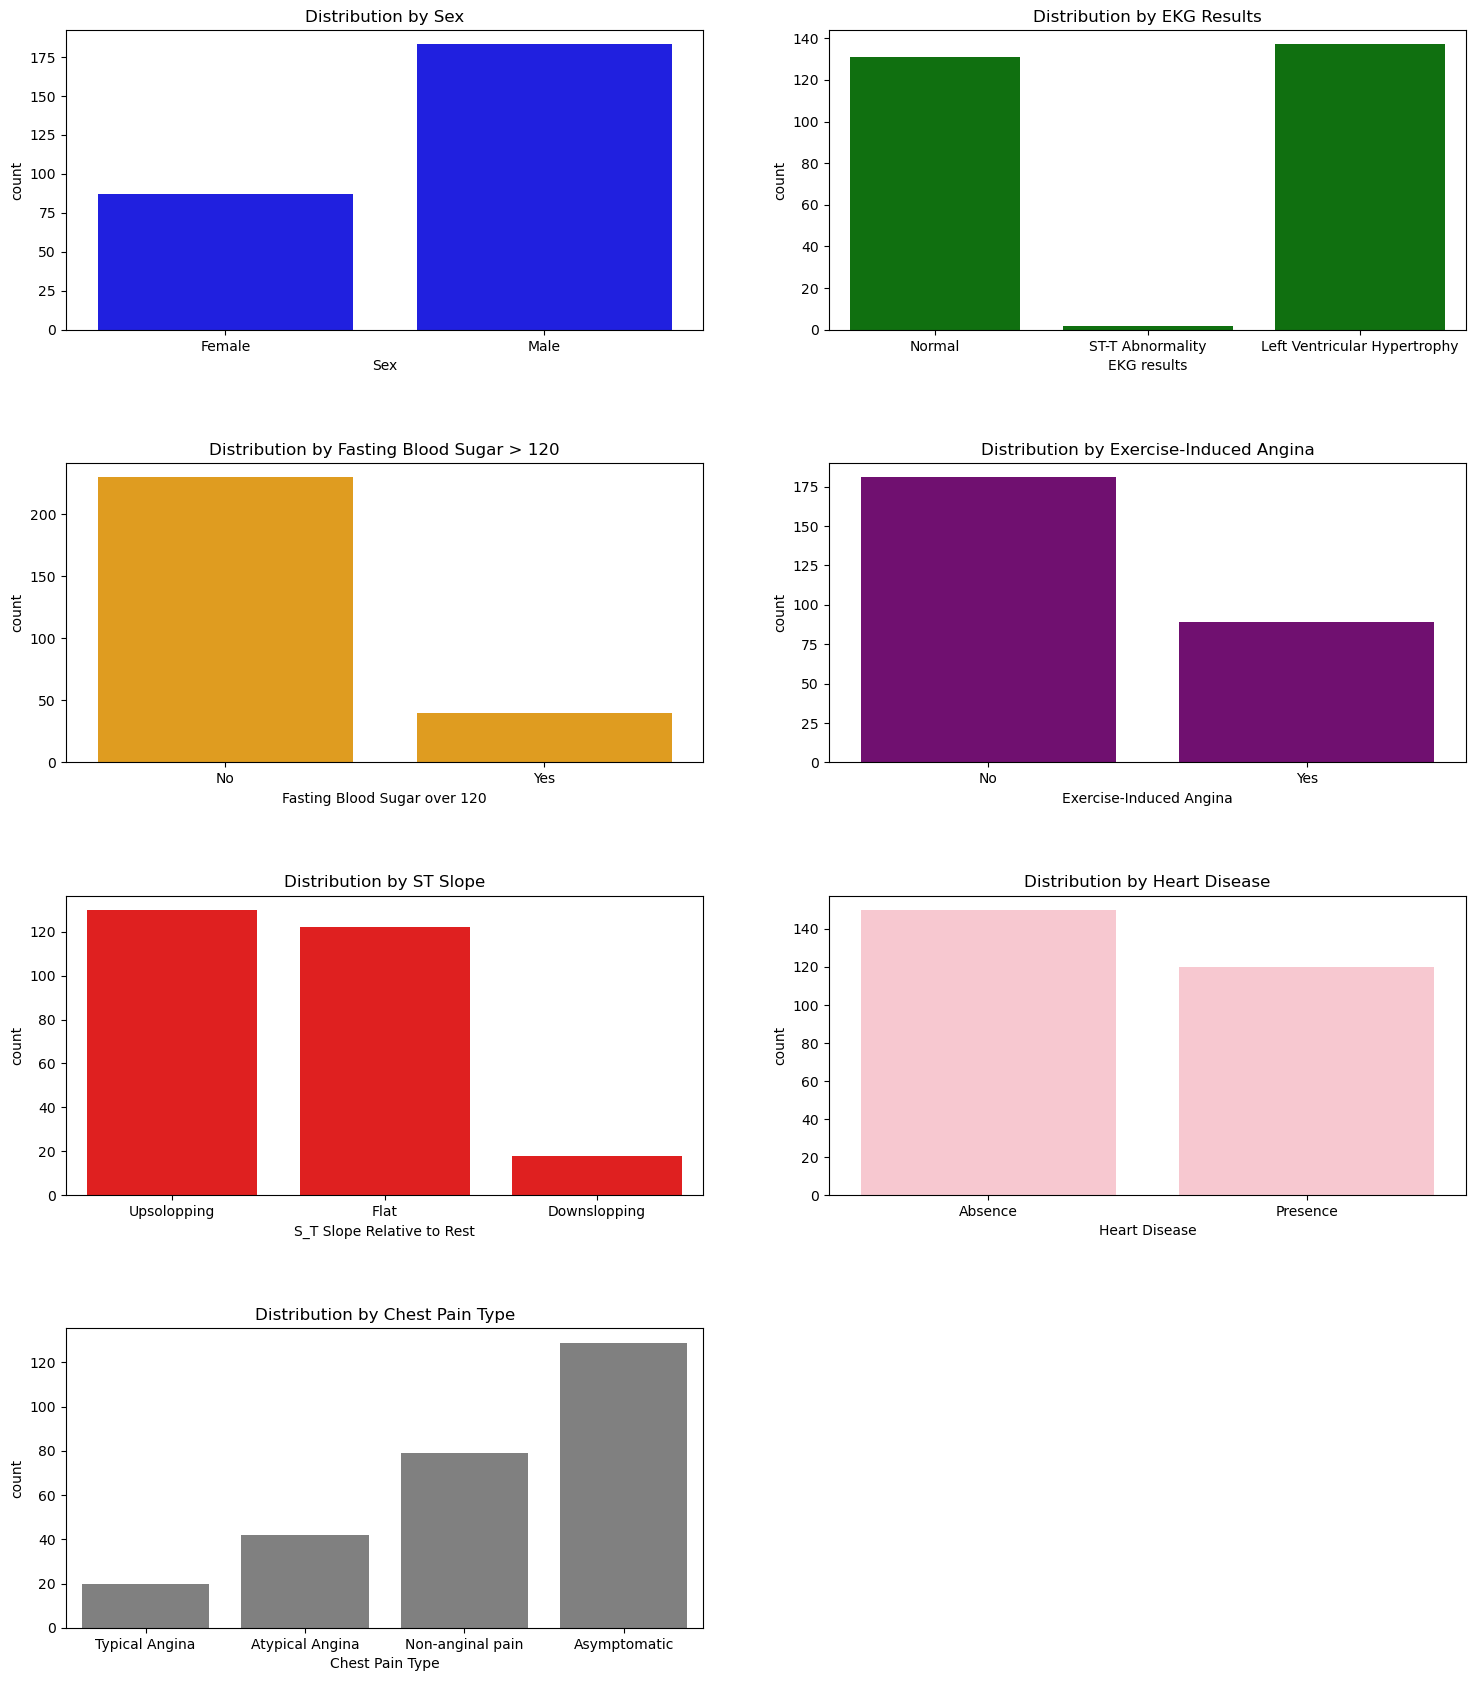

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))

# Plotting each categorical variable
sns.countplot(x='Sex', data=heart_modified, ax=axes[0, 0], color="Blue")
axes[0, 0].set_title('Distribution by Sex')

sns.countplot(x='EKG results', data=heart_modified, ax=axes[0, 1], color="Green")
axes[0, 1].set_title('Distribution by EKG Results')

sns.countplot(x='Fasting Blood Sugar over 120', data=heart_modified, ax=axes[1, 0], color="Orange")
axes[1, 0].set_title('Distribution by Fasting Blood Sugar > 120')

sns.countplot(x='Exercise-Induced Angina', data=heart_modified, ax=axes[1, 1], color="Purple")
axes[1, 1].set_title('Distribution by Exercise-Induced Angina')

sns.countplot(x='S_T Slope Relative to Rest', data=heart_modified, ax=axes[2, 0], color="Red")
axes[2, 0].set_title('Distribution by ST Slope')

sns.countplot(x='Heart Disease', data=heart_modified, ax=axes[2, 1], color="pink")
axes[2, 1].set_title('Distribution by Heart Disease')

sns.countplot(x='Chest Pain Type', data=heart_modified, ax=axes[3, 0], color="grey")
axes[3, 0].set_title('Distribution by Chest Pain Type')

# Turnning off the last empty subplot (axes[2, 1]) _ otherwise, we would have an empty plot!
fig.delaxes(axes[3, 1])

plt.tight_layout(pad=5)  
plt.show()

The visualization shows that the dataset includes nearly twice as many male subjects as female subjects. It is also apparent that a large proportion of subjects do not have fasting blood sugar over 120 or experience exercise-induced angina. There is also a relatively small proportion of subjects with a downsloping ST slope compared to those with upsloping or flat ST slopes. In addition, we can see that only a small proportion of subjects show ST-T abnormalities. The asymptomatic chest pain type is the most prevalent among individuals and the Typical Angina is the rarest chest pain type among individuals. Finally, the heart disease is absent for majority of the individuals in the dataset, with the difference being relatively small compared to those who are diagnosed with having the disease. 

#### 3-2-2) Univariate Countplots with Hue ####

For this purpose, we can plot various categorical variables, using the single variable as the hue, which allows to observe how it influences the distribution of the other variables. However, since it would be time-consuming and intensive, we decided to focus on two key variables for this analysis to simplify the visualization process:

- *Heart Disease*: Because this is the main outcome we aim to predict, it provides the most relevant context for the analysis.

- *Sex*: Gender is also an interesting varibale that usually stimulates questions concerning the potential gender effects in a variablity 

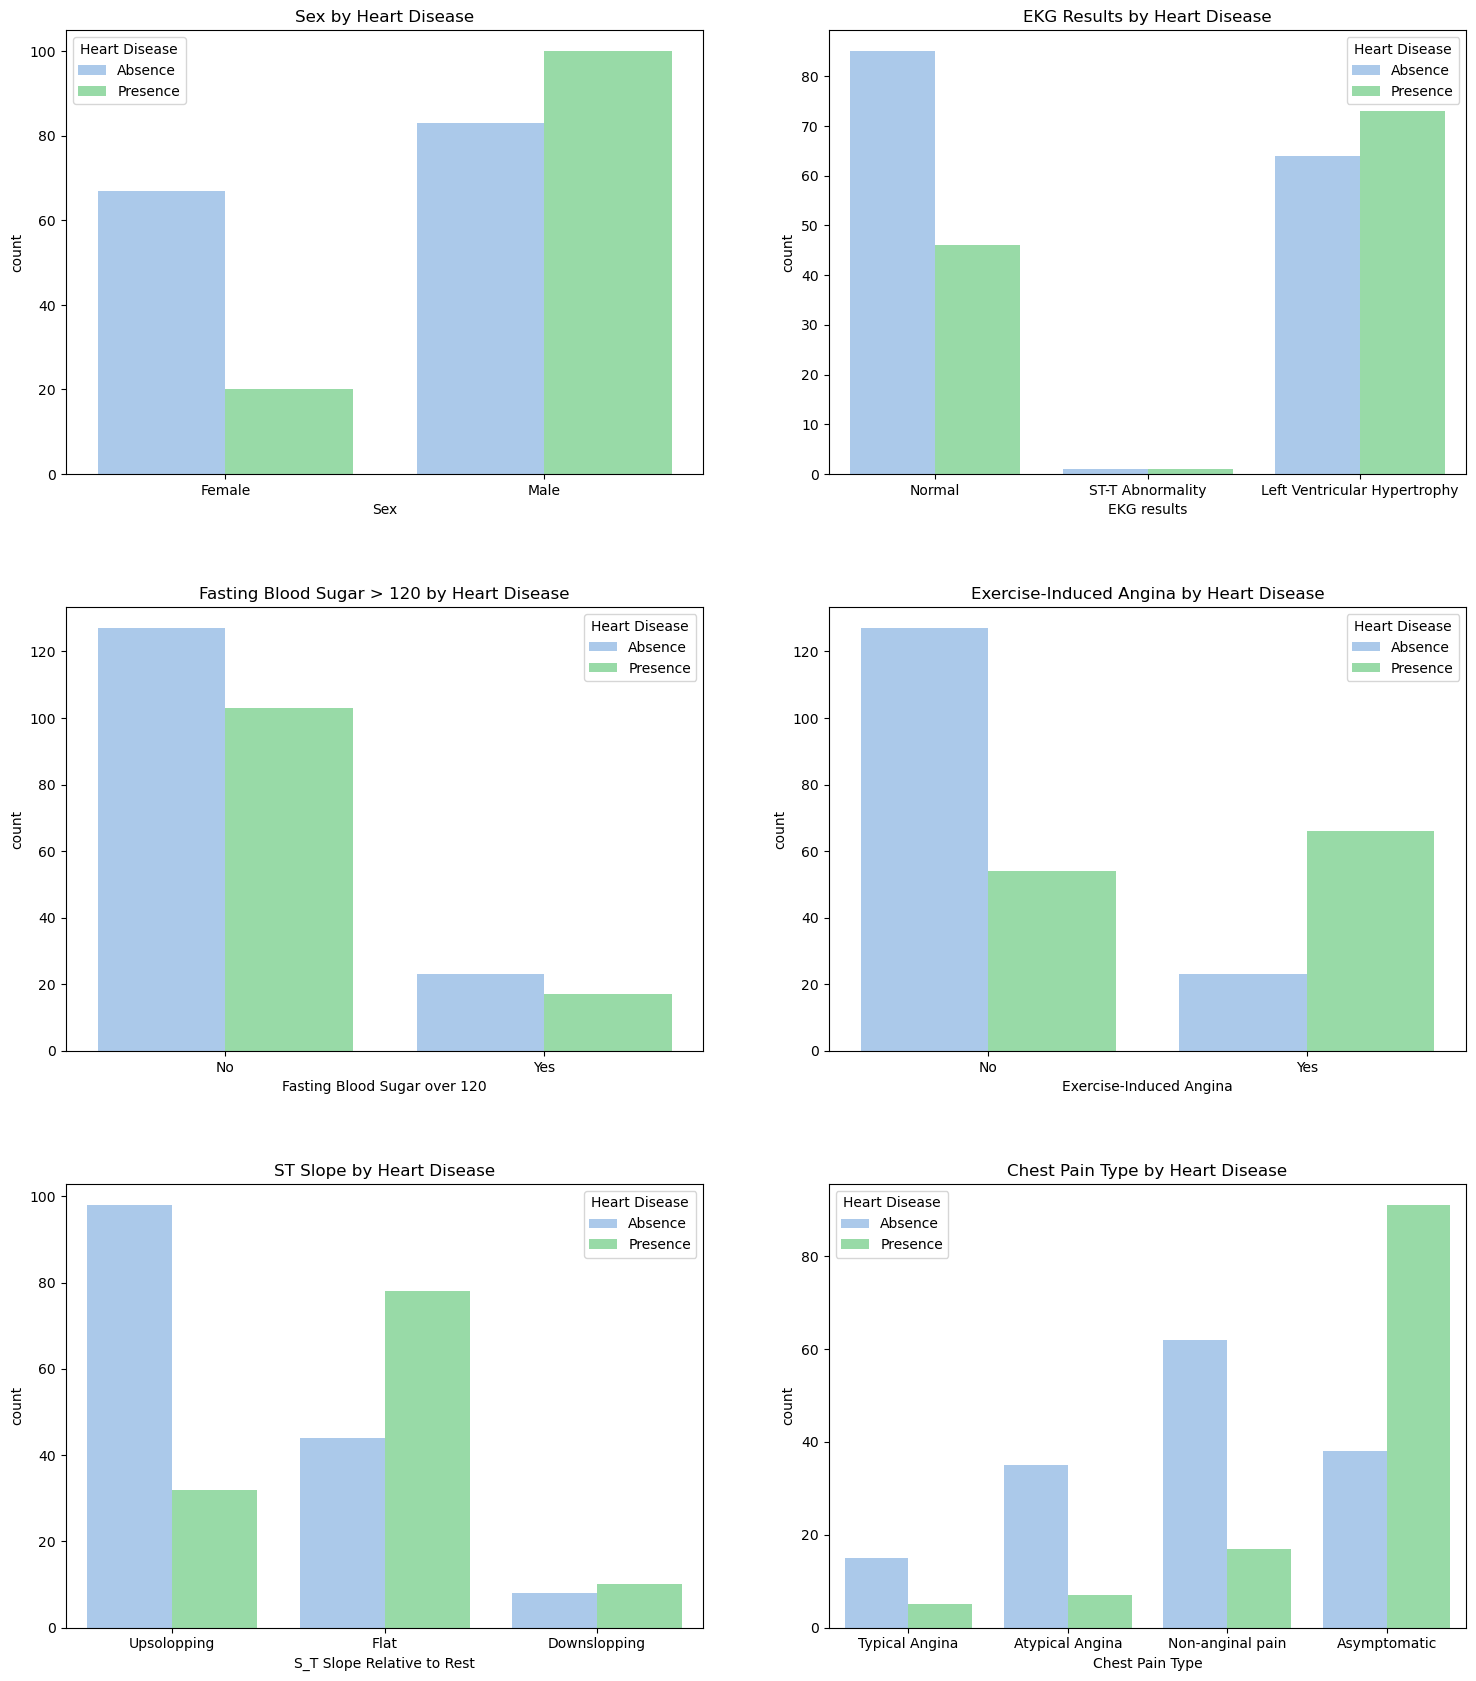

In [14]:
# Plotting each countplot with x='different variables' and hue as 'Hear Disease'

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
sns.set_palette("pastel6")  

sns.countplot(x='Sex', data=heart_modified, hue="Heart Disease", ax=axes[0, 0])
axes[0, 0].set_title('Sex by Heart Disease')

sns.countplot(x='EKG results', data=heart_modified, hue="Heart Disease", ax=axes[0, 1])
axes[0, 1].set_title('EKG Results by Heart Disease')

sns.countplot(x='Fasting Blood Sugar over 120', data=heart_modified, hue="Heart Disease", ax=axes[1, 0])
axes[1, 0].set_title('Fasting Blood Sugar > 120 by Heart Disease')

sns.countplot(x='Exercise-Induced Angina', data=heart_modified, hue="Heart Disease", ax=axes[1, 1])
axes[1, 1].set_title('Exercise-Induced Angina by Heart Disease')

sns.countplot(x='S_T Slope Relative to Rest', data=heart_modified, hue="Heart Disease", ax=axes[2, 0])
axes[2, 0].set_title('ST Slope by Heart Disease')

sns.countplot(x='Chest Pain Type', data=heart_modified, hue="Heart Disease", ax=axes[2, 1])
axes[2, 1].set_title('Chest Pain Type by Heart Disease')

plt.tight_layout(pad=5)
plt.show()

#### Interpretation of relationship between Heart Disease and other categorical varibales :

Based on the of plots illustrated above, several clear trends can be mentioned concerning the relation between *"Heart Disease"* categorical variable and other categorical variables:

1)  ##### *Sex and Heart disease:*
    In the dataset, among individuals with heart disease, males are significantly more represented than females. When we look within each gender (intra-class comparison), a higher proportion of men have heart disease compared to those without it. This is while among females, there are more individuals without heart disease than those having the disease. This trend suggests that within this dataset, males have a higher likelihood of being diagnosed with heart disease compared to females.

2)  ##### *EKG Results and Heart disease:*
      Examining the relationship between EKG results and heart disease, we see that ST-T Abnormality is not a reliable predictor of heart disease, as individuals with this result are relatively balanced in terms of disease presence and absence. Also, Left Ventricular Hypertrophy also does not appear to be a strong predictor of heart disease, as the proportion of individuals with this condition is similar for both those with and without heart disease.Finally, for subjects with Normal EKG results, heart disease is absent in about half of the cases, suggesting no strong pattern to indicate that "Normal" EKG results are a significant predictor of heart disease either.
3)  ##### *Fasting Blood Sugar over 120 and Heart disease:*
      For subjects with fasting blood sugar levels over 120, the proportions of individuals with and without heart disease are roughly similar. Likewise, for those with fasting blood sugar levels below 120, the proportion of subjects with or without the disease are approximately similar. This suggests that fasting blood sugar levels over 120 may not be a strong predictor of heart disease, as the presence or absence of disease does not show significant variation based on this threshold.
4)  ##### *Exercise-Induced Angina and Heart disease:*
      Individuals with exercise-induced angina have a high prevalence of heart disease, making it a strong risk indicator. Although, The absence of exercise-induced angina does not guarantee the absence of heart disease, it is generally associated with a lower prevalence.
5)  ##### *S_T Slope Relative to Rest and Heart disease:*
    The plot indicates that upslopping ST segment in EKG signal is associated with a higher likelihood of being healthy, as the majority of individuals with an upslope have no heart disease. In contrast, a flat ST slope shows a significant association with heart disease, with twice as many individuals having the disease compared to those without. The downsloping ST slope, though less common, also appears to be linked to heart disease presence, which together suggest that a downsloping or flat ST slope could be potential risk indicators for heart disease.
6)  ##### *Chest Pain Type and Heart disease:*
    For individuals experiencing one of the three categories of the chest pain type, namely "typical angina" , "Atypical angina" and "non-anginal pain" we can observe that the disease is commonly absent. However, for individuls having "Asymptomatic" chest pain type, the disease is significantly present, showing a strong relationship between heart disease and having asymptomatic chest pain type.

    

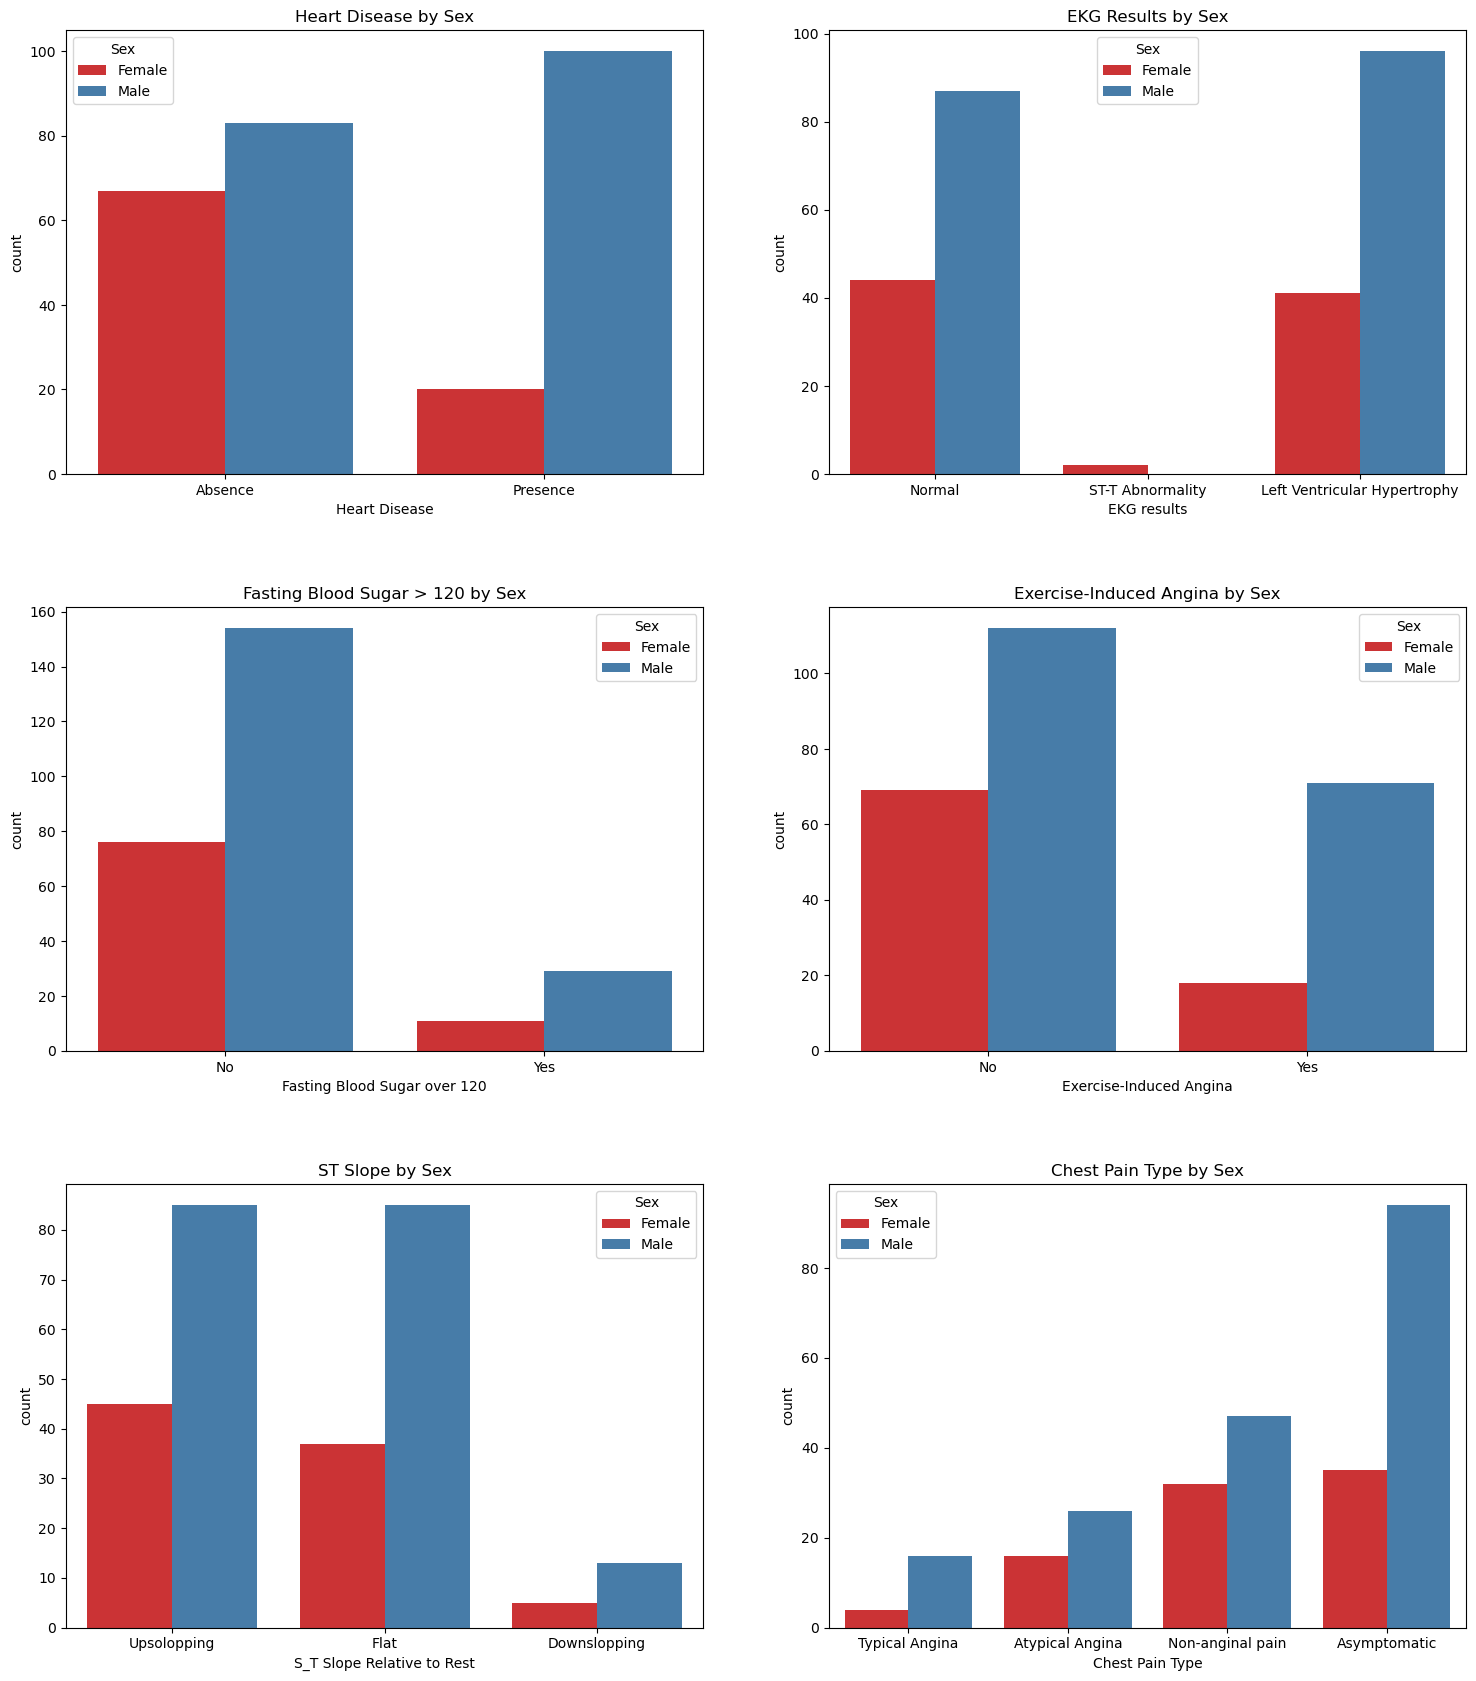

In [15]:
# Plotting each countplot with x='different variables' and hue as 'Sex'

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
sns.set_palette("Set1")  # Choose a color palette

# Plotting each countplot with hue as "Sex" and appropriate titles
sns.countplot(x='Heart Disease', data=heart_modified, hue="Sex", ax=axes[0, 0])
axes[0, 0].set_title('Heart Disease by Sex')

sns.countplot(x='EKG results', data=heart_modified, hue="Sex", ax=axes[0, 1])
axes[0, 1].set_title('EKG Results by Sex')

sns.countplot(x='Fasting Blood Sugar over 120', data=heart_modified, hue="Sex", ax=axes[1, 0])
axes[1, 0].set_title('Fasting Blood Sugar > 120 by Sex')

sns.countplot(x='Exercise-Induced Angina', data=heart_modified, hue="Sex", ax=axes[1, 1])
axes[1, 1].set_title('Exercise-Induced Angina by Sex')

sns.countplot(x='S_T Slope Relative to Rest', data=heart_modified, hue="Sex", ax=axes[2, 0])
axes[2, 0].set_title('ST Slope by Sex')

sns.countplot(x='Chest Pain Type', data=heart_modified, hue="Sex", ax=axes[2, 1])
axes[2, 1].set_title('Chest Pain Type by Sex')

plt.tight_layout(pad=5)  
plt.show()

#### Interpretation of relationship between Sex and other categorical varibales :

Based on the of plots illustrated above, several clear trends can be mentioned concerning the relation between *"Sex"* categorical variable and other categorical variables:

1)  ##### *Sex and Heart disease:*
    The trend previously observed is further confirmed by this plot, which demonstrates that males exhibit a significantly higher incidence of heart disease compared to females. The above plot indicates that the prevalence of heart disease is much less among females than males. 
2)  ##### *Sex and EKG Results:*
    The EKG Results by Sex plot shows that both males and females have roughly similar proportions of Normal and Left Ventricular Hypertrophy results, meaning that these conditions are equally prevalent within each gender group. However, the ST-T Abnormality is almost nonexistent in males, while it is rarely present in females, suggesting that ST-T Abnormality is more common among females.
3)  ##### *Sex and Fasting Blood Sugar over 120:*
      The plot indicates that majority of both males and females have fasting blood sugar levels below 120. Among those with fasting blood sugar levels above 120, there are more males than females, but the difference is relatively small.
4)  ##### *Sex and Exercise-Induced Angina:*
      A higher count of both males and females do not experience exercise-induced angina, with males representing a slightly larger proportion. following a similar trend with Fasting blood sugar over 120, among those who do experience exercise-induced angina, males are more prevalent than females.
5)  ##### *Sex and S_T Slope Relative to Rest:*
       "Upsloping" and "Flat" ST slopes are observed more frequently in males, with a smaller proportion in females. This is consistent with the plots of previous section indicating flat ST slope is strongly associated with presence of the disease and the fact that the disease is more prevalent in males than females. "Downsloping" ST slope is relatively uncommon, but it is more frequent in males than females.
6)  ##### *Sex and Chest Pain Type:*
       The plot shows that a significant proportion of males, which is more than twice of the females, were experiencing Asymptomatic chest pain type. The trend is almost similar for other chest pain types.    

## 4) **Summary of Data Exploration Results and Analysis Perspectives** ## 

To summarize the data explorations, we found that:

- Males show a higher prevalence of heart disease than females, suggesting a potential gender-related risk factor.
- No strong predictive patterns are observed for EKG results varibale, but flat or downsloping ST slopes correlate with heart disease presence.
- Fasting blood sugar over 120 does not show a significant association with heart disease presence.
- Exercise-Induced Angina is strongly correlated with heart disease and absence of angina correlates with lower prevalence.
- Asymptomatic chest pain shows a strong association with heart disease, while other types are less indicative.

From these findings, we can conclude that in general, the two categorical variables of fasting blood sugar over 120 mg/dl and EKG results are weak predictors of heart disease, since they don’t show a strong association with presence of heart disease. However, other categorical variables including sex, exercise-induced angina, ST-slope and chest pain type are more informative. Although they cant not be considered as perfect distinctive predictors for the presence of heart disease, individuals experiencing one of the conditions of these categorical varibales seems to have an increased likelihood of having heart disease by about 50%. This makes these categorical varibales useful for assessing risk when combined with other indicators.

In the next section, the aim is to explore the combined effects of these selected categorical variables with key quantitative variables like age, cholesterol, and max heart rate, to discover more detailed insights into heart disease predictors. This Includes asking relevant questions, as well as performing bivariate analysis to identiify some patterns in the distributions.


## 5) **Formulating questions, answering them with operations/graphs, and discussing the results** ## 



### 5.1) Performing Bivariate and Multivariate Analysis ###


#### Question 1: What is the relationship between Gender and Prescence of Heart Disease? ####

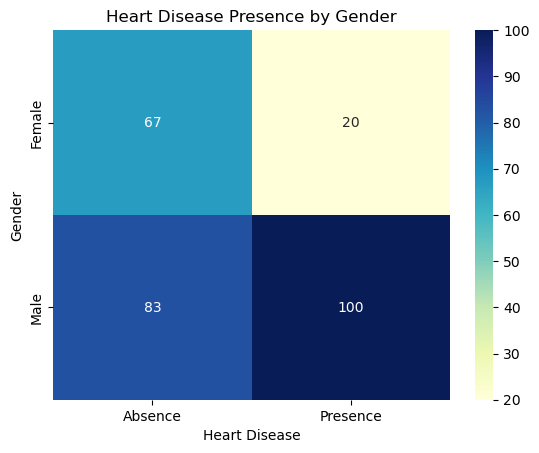

In [16]:
data_crosstab = pd.crosstab(heart_modified['Sex'], heart_modified['Heart Disease'])

# Plot the heatmap
sns.heatmap(data_crosstab, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Heart Disease Presence by Gender")
plt.xlabel("Heart Disease")
plt.ylabel("Gender")
plt.show()

Based on the data provided in the heatmap, among males, there is a higher number of individuals with heart disease compared to those without. Specifically, 100 males have heart disease, while 83 males do not. This contrasts with the female category, where only 20 females have heart disease, while 67 females do not. This indicates that in this dataset, females have a lower likelihood of heart disease compared to males (almost five times less).Therefore, we can conclude that  gender could play a role in the risk of heart disease.

#### Question 2) Are there gender-specific differences in the distribution of Maximum Heart Rate?


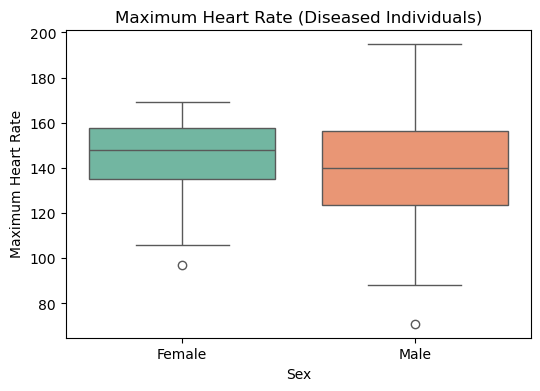

100
20


In [17]:
# Filtering the diseased males
male_diseased_data = heart_modified[(heart_modified['Heart Disease'] == "Presence") & (heart_modified['Sex'] == 'Male')]

# Filtering the diseased females
female_diseased_data = heart_modified[(heart_modified['Heart Disease'] == "Presence") & (heart_modified['Sex'] == 'Female')]

# Combining the filtered data into a single dataset
diseased_data = pd.concat([male_diseased_data, female_diseased_data])

# Generating the box plot
plt.figure(figsize=(6, 4))
sns.boxplot(data=diseased_data, x='Sex', y="Maximum Heart Rate" , hue = "Sex" , palette='Set2')
plt.title("Maximum Heart Rate (Diseased Individuals)")
plt.show()


# Why we can not perform statistical test?

print(len(male_diseased_data.axes[0]))
print(len(female_diseased_data.axes[0]))


Based on the box plot, it can be seen that the averga maximum heart rate for diseased Females is higher than that of males. The ideal case would have been to conduct statistical significance tests to determine weather this differenc is random or is statistically significant. However, this is not possible since there is not enough data points for diseased females in the dataset. There are 100 male diseased subjects which is five times larger than the count of diseased females. Therefore, the statistical test is not possible to perform. This situation does not change unless aiming for making coparison between females and males as general categories.

#### Quesstion 3: Is the relationship between maximum heart rate and gender the same for healthy individuals as it is for diseased individual? how  does this relationship vary within each gender between healthy and diseased individuals?

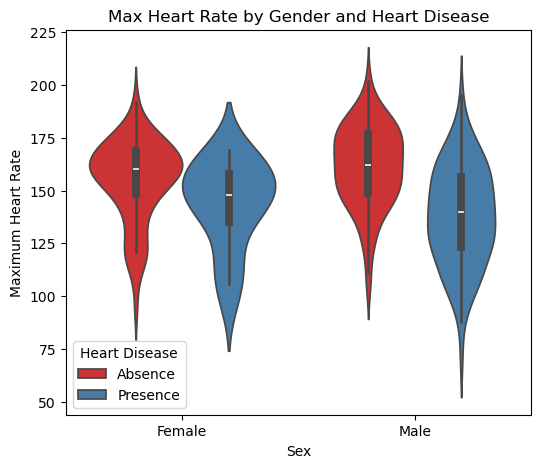

In [18]:
# Box plot: Maximum Heart Rate by Sex and Heart Disease
plt.figure(figsize=(6, 5))
sns.violinplot(data=heart_modified, x='Sex', y="Maximum Heart Rate", hue="Heart Disease", palette='Set1')
plt.title("Max Heart Rate by Gender and Heart Disease")
plt.show()


Despite the difference in the average maximum heart rate between diseased females and males, the violin plot indicates that the average maximum heart rate is almost identical between healthy male and female subjects. Also, the average maximum heart rate is higher in both males and females when compared to their healthy counterparts, with the difference being larger in males.

#### Question 4: Knowing the negative correlation existing between age and maximum heart rate, what does this imply for heart disease?

Text(0.5, 1.02, 'Age vs Maximum Heart Rate')

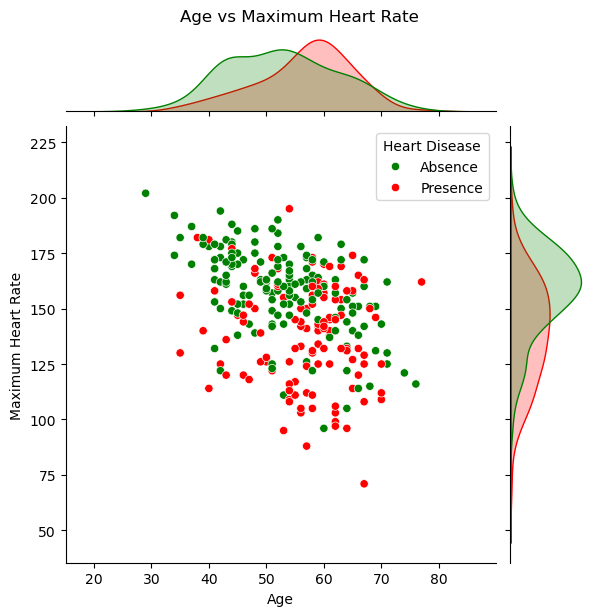

In [19]:
# Joint plot for Age vs Maximum Heart Rate
sns.jointplot(data=heart_modified, x='Age', y='Maximum Heart Rate', hue='Heart Disease', 
              palette=['green', 'red'], height=6).fig.suptitle('Age vs Maximum Heart Rate', y=1.02)



It was previously observed from the heatmap that there exists a moderate negative correlation between Age and Maximum heart rate of an individual. However, the heat map was not providing any insights into the effect of such relation on having heart disease. The above joointplot is properly answering this question. Based on the joint plot, we can see that Individuals without heart disease are mostly having higher maximum heart rate (among 150 - 175). Although a proportion of individuals with relatively low maximum heart rate are bseen in the category of healthy individuals, this proportion is higher in distribution of individuals with heart disease. Concerning the age, the plot shows that most individuals with heart disease individuals age between almost 50 to 65 years old. Based on the age distribution we can claim that individuals aging less than 50 years are most likely not affected with heart disease.


#### Question 5 What are the average max heart rates for individuals with and without heart disease, and how do these averages support the visual findings for answering question 1?

In [20]:

# Calculate the mean Maximum Heart Rate by Heart Disease
print(heart_modified.groupby('Heart Disease', observed=True)['Maximum Heart Rate'].mean())

Heart Disease
Absence     158.333333
Presence    138.858333
Name: Maximum Heart Rate, dtype: float64


Individuals with heart disease have a 20 beats per minute (bpm) less average max heart rate compared to those without, which supports the visual separation of the peaks seen in the joint plot.

#### Question 6: How does the relationship between ST depression and max heart rate affects heart disease diagnosis?


Text(0.5, 1.02, 'S_T Depression vs Maximum Heart Rate')

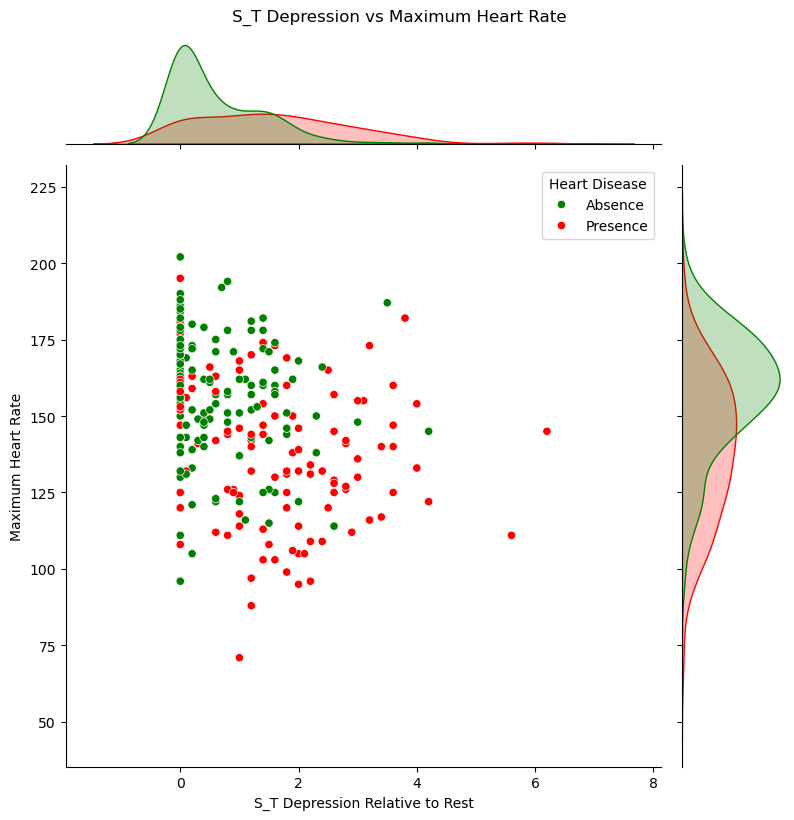

In [21]:
# Joint plot for ST Depression vs Maximum Heart Rate
sns.jointplot(data=heart_modified, x='S_T Depression Relative to Rest', y='Maximum Heart Rate', 
              hue='Heart Disease', palette=['green', 'red'], height=8).fig.suptitle('S_T Depression vs Maximum Heart Rate', y=1.02)

As it can be clearly seen from the above joint plot, for a significant proportion of healthy individuals, there is 0 value for S_T Depression relative to rest. This means that if there is no ST depression segment depression in EKG signal of an individual after doing exercise, The individual is most probably healthy. However, if this proportion surpasses 2, it is highly probable that the individual is having heart disease. Combined with the distrubution of Maximum heart rate, it can be claimed that healthy individuals have mostly higher maximum heart rate than diseased individuals and also smasller ST depression relative to rest.

#### Question 7) How is the variation in Resting Blood Pressure and Maximum Heart Rate between individuals with and without heart disease influenced by Chest Pain Type?

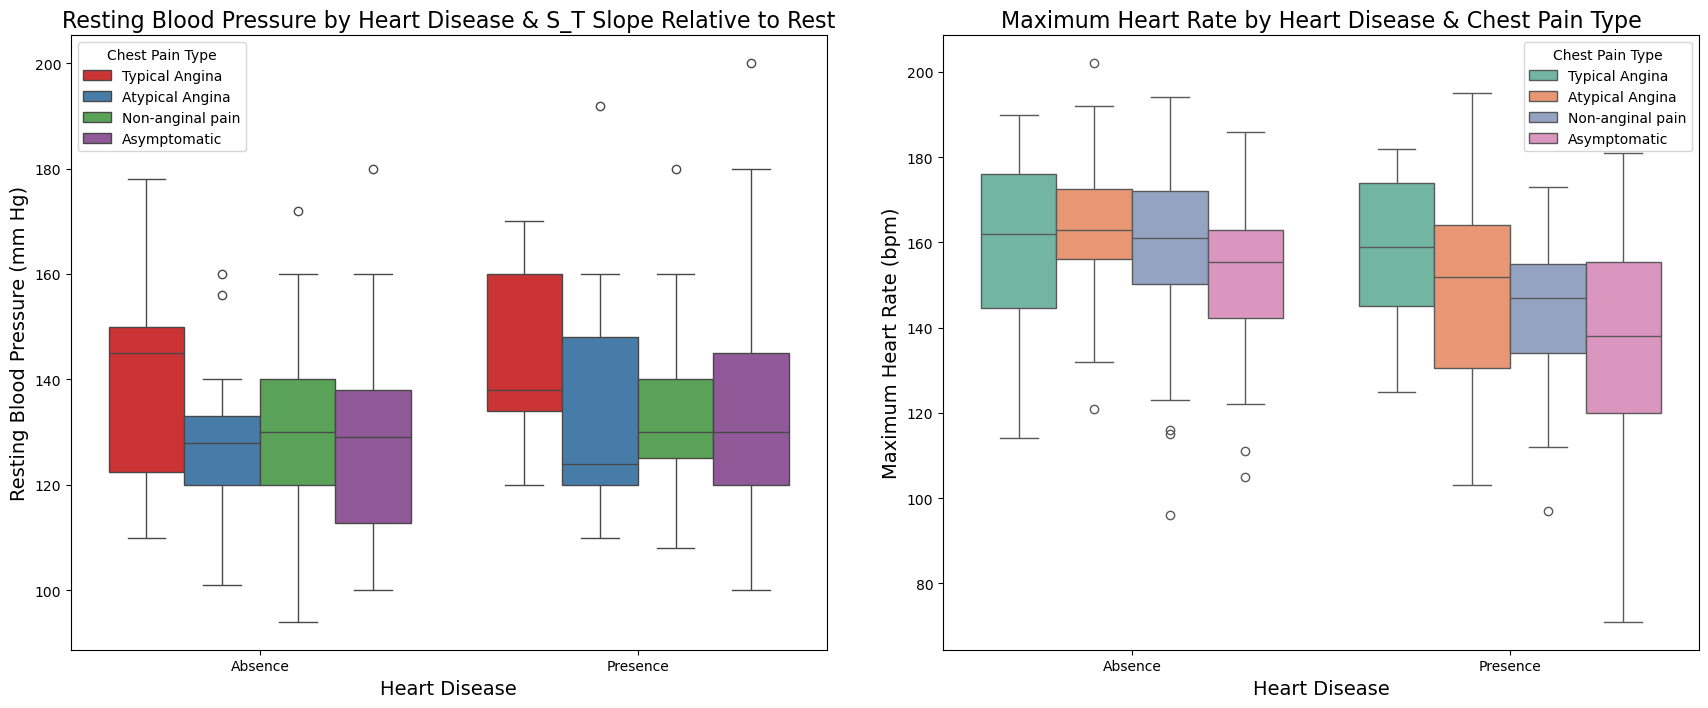

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Boxplot for EKG results vs Resting Blood Pressure
sns.boxplot(x='Heart Disease', y='Resting Blood Pressure', data=heart_modified, ax=axes[0], 
            hue='Chest Pain Type', palette='Set1')
axes[0].set_title('Resting Blood Pressure by Heart Disease & S_T Slope Relative to Rest', fontsize=16)
axes[0].set_xlabel('Heart Disease', fontsize=14)
axes[0].set_ylabel('Resting Blood Pressure (mm Hg)', fontsize=14)

# Boxplot for EKG results vs Maximum Heart Rate
sns.boxplot(x='Heart Disease', y='Maximum Heart Rate', data=heart_modified, ax=axes[1], 
            hue='Chest Pain Type', palette='Set2')
axes[1].set_title('Maximum Heart Rate by Heart Disease & Chest Pain Type', fontsize=16)
axes[1].set_xlabel('Heart Disease', fontsize=14)
axes[1].set_ylabel('Maximum Heart Rate (bpm)', fontsize=14)

plt.tight_layout(pad=4)
plt.show()



According to the box plots, we can say that individuals with heart disease generally show lower resting blood pressure compared to those without heart disease. This is consistent across chest pain types but is more significant for "Typical Angina" , which shows the highest median blood pressure value. Besides, individuals with "Atypical Angina" and "Non-anginal pain" have less extreme blood pressure values, suggesting a milde association with cardiovascular risks.

Concerning the maximum heart rate, individuals with heart disease consistently achieve lower maximum heart rates during exercise compared to those without heart disease, which can be asign of their reduced cardiac function. This trend is irrespective of their chest pain type. across all chest pain types."Non-anginal pain" and "Atypical Angina" in heart disease Absence are associated with higher maximum heart rates, reflecting better cardiovascular fitness. This is while diseased individuals with "Asymptomatic" chest pain type have the lowest median maximum heart rates. This can be considered probably as a factor of reduced cardiac activity and severity o disease.


### 5.2) Training a Machine Learning model for heart disease prediction ###


Having gained valuable insights from the analysis performed in the previous sections, it is now possible to train a machine learning model in order to predict heart disease given patients data. As discussed during the course, we will employ a KNN model for this purpose through the following steps.

#### 5.2.1) Encoding ####

We encode categorical variables because machine learning models require numerical input. One-hot encoding converts categories into binary columns, ensuring no unintended relationships between them. This allows models to process both numerical and categorical data seamlessly.

#### Question 9) Are the six key features that we described in data analysis part effective in predicting the presence of heart disease in individuals? can we verify the results of our analysis through testing the prediction using a machine learning KNN model?


Previously, we concluded that among the categorical variables, the three parameters of "Sex", "Chest Pain Type", "Exercise-Induced Angina" are the key features to be used for heart disease prediction. Additionally we found that 'Age', 'Maximum Heart Rate', 'S_T Depression Relative to Rest' are the three key numerical parameters that are also effective in prediction of heart disease in an individual. Now the strategy would be to compare the accuracy of prediction in two scenarios:

1) When the model is trained on all the categorical and numerical parameters **(12 parameters)**
2) When the model is only trained on a key subset of parameters that we detected through our analysis **(6 parameters)**

with this approach, we can verify the findings of our analysis and rely on thes subset of parameters for prediction of disease presence This would allow to cut the costs for recording the other data and saving data acquisition time.

#### 5.2.2) Training the KNN model on all parameters

In [250]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Selected features
numerical_features = heart_modified.select_dtypes(include=['float64', 'int64']).columns
categorical_features = heart_modified.select_dtypes(include=['category']).columns

# Preprocessing the data --> Standardizing numerical features and applying one-hot encoding for our selected categorical varibales

X = pd.DataFrame(StandardScaler().fit_transform(heart_modified[numerical_features]), columns=numerical_features).join(
    pd.DataFrame(OneHotEncoder(sparse_output=False).fit_transform(heart_modified[categorical_features]),
                 columns=OneHotEncoder(sparse_output=False).fit(heart_modified[categorical_features]).get_feature_names_out(categorical_features))
)

y = heart_modified["Heart Disease"]

# Splitting the data into training and testing sets (20 % test and 80% for train)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# Initializing the KNN model
knn = KNeighborsClassifier(n_neighbors=8)  # This k value was found to yeild the most optimal accuracy (k=2 yielded 98% accuracy which seemed like to be overfitting!)

# Performing 5-fold cross-validation
cv_scores = cross_val_score(knn, X_train, y_train, cv=5) # cv = 5 yielded the best score
print(f"cv_scores {cv_scores.mean():.2f}+/-{cv_scores.std():.2f}")

# Training the model 
knn.fit(X_train, y_train)

# Predicting on the test set
y_pred = knn.predict(X_test)

# Evaluating performance of the model using the confusion matrix and accuracy score
accuracy = accuracy_score(y_test, y_pred) # or similarly we could use the command "knn.score(X_test, y_test)" to simply evaluate the accuracy (as we did during the course)
print(f"Test Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

cv_scores 0.94+/-0.03
Test Accuracy: 0.91

Confusion Matrix:
 [[33  4]
 [ 1 16]]


The hyperparameter of the model was chosen experimentally for yielding the best results. we see that in this scenario, the model achieved an accuracy of 94% across the cross-validation folds, with a small variability of 3%. This is a strong indication that the model is performing well and is likely not overfitting. Besides, the accuracy on the test set is 91%, which is very close to the cross-validation score. Again, this suggests that the model generalizes well to unseen data and is not overfitting to the training set.

The confusion matrix was also coded to better undrestand the performance of the model. we can see that among the entire test set samples, there were only 4 false positives and 1 false negative classifications. This means that the model makes good predictions and distinguishes well between individuals with and without heart disease.

These are the prediction results using the entire set of parameters for training the model. 

#### 5.2.3) Training the KNN model on key parameters 

In [252]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Definign our 6 selected features
numerical_features = ['Age', 'Maximum Heart Rate', 'S_T Depression Relative to Rest']
categorical_features = ["Sex", "Chest Pain Type", "Exercise-Induced Angina"]

# Preprocessing the data --> Standardizing numerical features and applying one-hot encoding for our selected categorical varibales

X = pd.DataFrame(StandardScaler().fit_transform(heart_modified[numerical_features]), columns=numerical_features).join(
    pd.DataFrame(OneHotEncoder(sparse_output=False).fit_transform(heart_modified[categorical_features]),
                 columns=OneHotEncoder(sparse_output=False).fit(heart_modified[categorical_features]).get_feature_names_out(categorical_features))
)

y = heart_modified["Heart Disease"]

# Splitting the data into training and testing sets (20 % test and 80% for train)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# Initializing the KNN model
knn = KNeighborsClassifier(n_neighbors=8)  # This k value was found to yeild the most optimal accuracy

# Performing 5-fold cross-validation
cv_scores = cross_val_score(knn, X_train, y_train, cv=5) # cv = 5 yielded the best score
print(f"cv_scores {cv_scores.mean():.2f}+/-{cv_scores.std():.2f}")

# Training the model 
knn.fit(X_train, y_train)

# Predicting on the test set
y_pred = knn.predict(X_test)

# Evaluating performance of the model using the confusion matrix and accuracy score
accuracy = accuracy_score(y_test, y_pred) # or similarly we could use the command "knn.score(X_test, y_test)" to simply evaluate the accuracy (as we did during the course)
print(f"Test Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


cv_scores 0.78+/-0.02
Test Accuracy: 0.85

Confusion Matrix:
 [[31  6]
 [ 2 15]]


After tuning the parameters, the above results were achieved. The results show that on average, our model achieves an accuracy of 78% when performing 5-fold cross-validation on the training data. In other words, during the cross-validation process, the model was tested on 5 different subsets of the data, and it was able to correctly classify 78% of the samples on average. However, there has been a low standard deviation of 2% which indicates that there is a minimal variation in accuracy between the folds. 

We also see that when the model was applied to our test dataset as a new and unseen data, it correctly predicted the target variable for 85% of the samples, which is satisfactory. The confusion matrix was also generated to allow for better undrestanding of the model performance. it shows that our model correctly predicted presence of heart disease in 15 cases, and absence of heart disease in 31 cases. However, there were 6 cases where the model incorrectly predicted presence when the correct label was absence, and 2 cases where it predicted absence when the correct label was presence.

By comparison, we observe that there is less than 10 % of decrease in the prediction accuracy of the KNN model, if we take into account only six key parameters for heart disease presence prediciton. This last comparison is verifying our entire analyis by showing that prediction is still reboust if considering the six key parameters that we found.

## 6) **Conclusion of the Analysis**

#### Quality of Dataset ####
The dataset provides a foundation for analyzing the relationship between resting blood pressure and Age group. While it is sufficient for basic classification tasks, its small size, consisting of 270 rows, restrict the depth of analysis and prediction power of machine learning models. Some columns had incorrect datatypes such as categorical features being represented as floats or integers, leading to errors during training machine learning models as models may misinterpret categorical variables cannot be directly processed. To address this, One-hot encoding was applied to categorical variables to create binary columns for each category ensuring seamless process of both numerical and categorical data. 

#### Possible Improvements ####

#### Expand the Dataset: ####

1) Increase the dataset size by collecting more data points. A larger dataset would provide more diverse examples and improve the reliability of machine learning models.
2) Include a wider variety of individuals to better represent different age groups, genders, and health conditions.

#### Add Features: ####

1) Incorporate additional features that are known to impact blood pressure, such as:
Weight, BMI, and height.
Lifestyle factors (e.g., smoking, exercise, stress levels).
Medical history (e.g., history of hypertension, heart disease, or diabetes).
These features would allow for a more comprehensive analysis and potentially improve the model's predictive performance.

#### Address Data Imbalance: ####

1) If the dataset is imbalanced, apply techniques to handle this, such as:
Oversampling the minority class (e.g., SMOTE).
Undersampling the majority class.
2) Using weighted classification models to account for class imbalance.

#### Data Preprocessing: ####

Ensure that the data is clean and properly scaled. Normalize continuous variables (like RBP) to ensure they are on the same scale for models like KNN, which are sensitive to feature magnitude.

#### Expanding Dataset: ####
By expanding the dataset, including additional relevant features, and addressing potential imbalances, the quality of insights and model performance could be significantly improved.

#### Suggestions for further Analysis: ####
1) Further analysis could focus on incorporating lifestyle and medical history data, experimenting with advanced models, and exploring longitudinal trends in blood pressure for a more comprehensive understanding of hypertension risks.

#### 2) Exploratory Data Analysis (EDA): ####

Conduct a deeper analysis of the distribution of blood pressure across different age groups and genders.
Identify potential outliers in the data and understand their impact on model performance.

#### 3) Refine Model Performance: ####

Experiment with different machine learning algorithms in addition to KNN, such as:
i) Logistic Regression.
ii) Decision Trees or Random Forests.
iii) Support Vector Machines (SVMs).
iv) Compare model performance using metrics like accuracy, F1-score, precision, and recall.

#### 4) Cluster Analysis: ####

Use unsupervised learning methods (e.g., K-Means Clustering) to identify natural groupings in the data, such as clusters of individuals with similar blood pressure profiles.

#### 5) Analyze Risk Factors: ####

Explore correlations between RBP and other available variables to identify risk factors for high blood pressure.

#### 6) Time-Based Analysis: ####

If longitudinal data is available, analyze how blood pressure changes over time for individuals, and predict trends using regression models.


## 7) **Bibliographic References**

https://www.kaggle.com/datasets/rishidamarla/heart-disease-prediction/code